In [2]:
import os

data_dir = "../data/database_nifti/database_nifti"
patient = "patient0001"
patient_path = os.path.join(data_dir, patient)

print("Files in patient0001:")
for f in os.listdir(patient_path):
    print(f)

Files in patient0001:
Info_2CH.cfg
Info_4CH.cfg
MANDATORY_CITATION.md
patient0001_2CH_ED.nii.gz
patient0001_2CH_ED_gt.nii.gz
patient0001_2CH_ES.nii.gz
patient0001_2CH_ES_gt.nii.gz
patient0001_2CH_half_sequence.nii.gz
patient0001_2CH_half_sequence_gt.nii.gz
patient0001_4CH_ED.nii.gz
patient0001_4CH_ED_gt.nii.gz
patient0001_4CH_ES.nii.gz
patient0001_4CH_ES_gt.nii.gz
patient0001_4CH_half_sequence.nii.gz
patient0001_4CH_half_sequence_gt.nii.gz


Image shape: (549, 389)
Mask shape: (549, 389)
Unique mask values: [0. 1. 2. 3.]


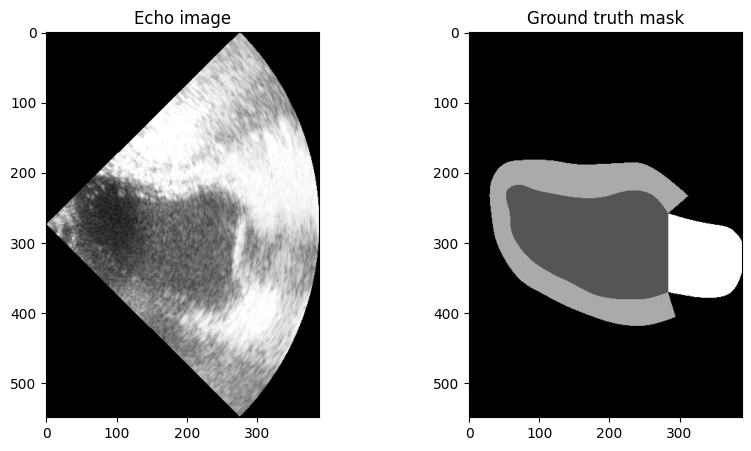

In [3]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import os

data_dir = "../data/database_nifti/database_nifti"
patient = "patient0001"
img_path = os.path.join(data_dir, patient, f"{patient}_2CH_ED.nii.gz")
gt_path = os.path.join(data_dir, patient, f"{patient}_2CH_ED_gt.nii.gz")

img = nib.load(img_path).get_fdata()
gt = nib.load(gt_path).get_fdata()

print(f"Image shape: {img.shape}")
print(f"Mask shape: {gt.shape}")
print(f"Unique mask values: {np.unique(gt)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Echo image')
axes[1].imshow(gt, cmap='gray')
axes[1].set_title('Ground truth mask')
plt.show()

In [5]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.pool = nn.MaxPool2d(2)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.final = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

model = UNet()
x = torch.randn(1, 1, 256, 256)
out = model(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {out.shape}")
print("Model OK")

Input shape: torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 4, 256, 256])
Model OK


In [6]:
import cv2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class CAMUSDataset(Dataset):
    def __init__(self, data_dir, samples, img_size=256):
        self.data_dir = data_dir
        self.samples = samples
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, gt_path = self.samples[idx]
        img = nib.load(img_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        img = cv2.resize(img.astype(np.float32), (self.img_size, self.img_size))
        gt = cv2.resize(gt.astype(np.float32), (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        gt = torch.tensor(gt, dtype=torch.long)

        return img, gt

# Build sample list
all_samples = []
for patient in sorted(os.listdir(data_dir)):
    patient_path = os.path.join(data_dir, patient)
    if not os.path.isdir(patient_path):
        continue
    for view in ['2CH', '4CH']:
        for phase in ['ED', 'ES']:
            img_file = os.path.join(patient_path, f'{patient}_{view}_{phase}.nii.gz')
            gt_file = os.path.join(patient_path, f'{patient}_{view}_{phase}_gt.nii.gz')
            if os.path.exists(img_file) and os.path.exists(gt_file):
                all_samples.append((img_file, gt_file))

print(f"Total samples: {len(all_samples)}")

train_samples, val_samples = train_test_split(all_samples, test_size=0.2, random_state=42)
train_dataset = CAMUSDataset(data_dir, train_samples)
val_dataset = CAMUSDataset(data_dir, val_samples)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Total samples: 2000
Train: 1600 | Val: 400


In [7]:
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

def dice_score(pred, target, num_classes=4):
    pred = torch.argmax(pred, dim=1)
    dice = 0
    for c in range(1, num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()
        intersection = (pred_c * target_c).sum()
        dice += (2 * intersection + 1e-8) / (pred_c.sum() + target_c.sum() + 1e-8)
    return dice / (num_classes - 1)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_dice = 0, 0
    with torch.set_grad_enabled(train):
        for imgs, masks in tqdm(loader, leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = criterion(preds, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(preds, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

EPOCHS = 20
best_dice = 0
for epoch in range(EPOCHS):
    train_loss, train_dice = run_epoch(train_loader, train=True)
    val_loss, val_dice = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Dice: {train_dice:.4f} | Val Loss: {val_loss:.4f} Dice: {val_dice:.4f}")
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), '../results/best_model.pth')
        print(f"  Model saved (best dice: {best_dice:.4f})")

Using device: cpu


Epoch 1/20 | Train Loss: 0.5656 Dice: 0.7372 | Val Loss: 0.3297 Dice: 0.8303
  Model saved (best dice: 0.8303)


Epoch 2/20 | Train Loss: 0.2303 Dice: 0.8577 | Val Loss: 0.1796 Dice: 0.8610
  Model saved (best dice: 0.8610)


Epoch 3/20 | Train Loss: 0.1561 Dice: 0.8719 | Val Loss: 0.1373 Dice: 0.8791
  Model saved (best dice: 0.8791)


Epoch 4/20 | Train Loss: 0.1269 Dice: 0.8824 | Val Loss: 0.1307 Dice: 0.8742


...

Epoch 16/20 | Train Loss: 0.0638 Dice: 0.9268 | Val Loss: 0.0961 Dice: 0.8978


Epoch 17/20 | Train Loss: 0.0583 Dice: 0.9327 | Val Loss: 0.0879 Dice: 0.9096
  Model saved (best dice: 0.9096)


Epoch 18/20 | Train Loss: 0.0558 Dice: 0.9350 | Val Loss: 0.0940 Dice: 0.9036


Epoch 19/20 | Train Loss: 0.0562 Dice: 0.9347 | Val Loss: 0.0959 Dice: 0.9032


Epoch 20/20 | Train Loss: 0.0541 Dice: 0.9374 | Val Loss: 0.0952 Dice: 0.9058


C:\Users\Guillaume E\AppData\Local\Temp\ipykernel_29332\763843110.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../results/best_model

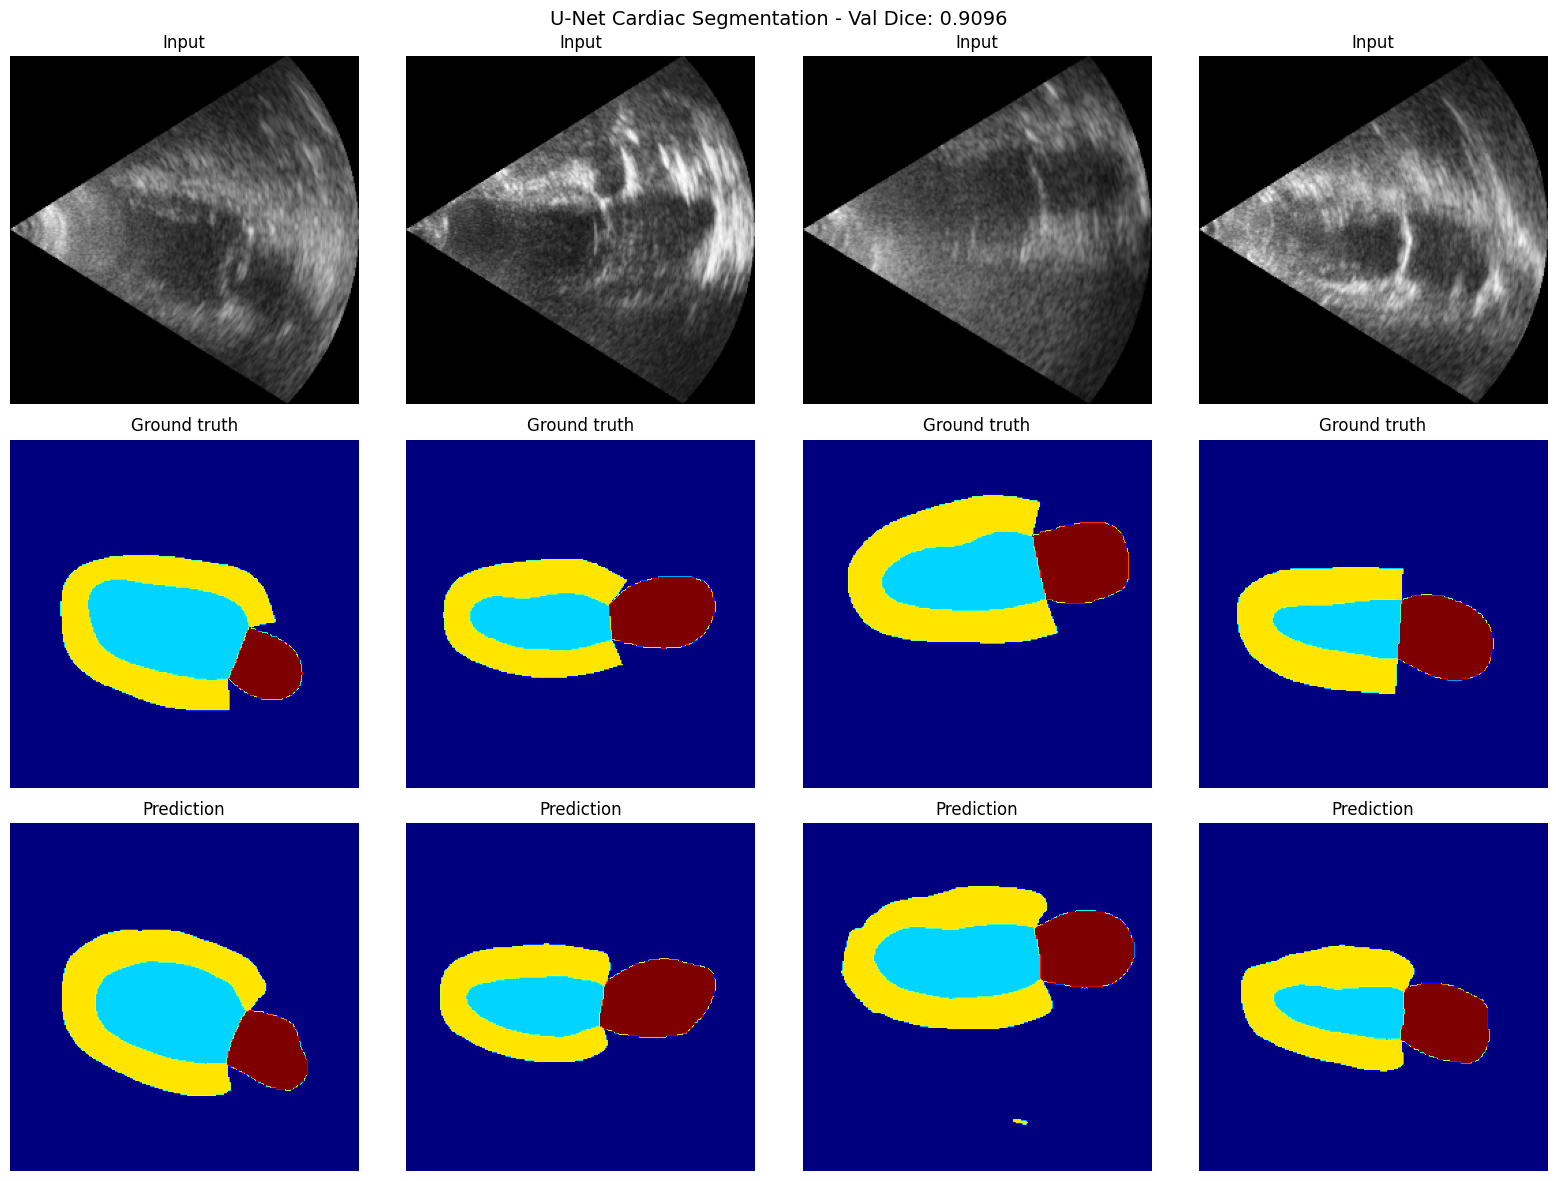

Saved to results/predictions.png


In [8]:
# Visualize predictions
model.load_state_dict(torch.load('../results/best_model.pth'))
model.eval()

imgs, masks = next(iter(val_loader))
with torch.no_grad():
    preds = model(imgs.to(device))
preds = torch.argmax(preds, dim=1).cpu()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i in range(4):
    axes[0, i].imshow(imgs[i, 0], cmap='gray')
    axes[0, i].set_title('Input')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i], cmap='jet', vmin=0, vmax=3)
    axes[1, i].set_title('Ground truth')
    axes[1, i].axis('off')
    axes[2, i].imshow(preds[i], cmap='jet', vmin=0, vmax=3)
    axes[2, i].set_title('Prediction')
    axes[2, i].axis('off')

plt.suptitle(f'U-Net Cardiac Segmentation - Val Dice: 0.9096', fontsize=14)
plt.tight_layout()
plt.savefig('../results/predictions.png', dpi=150)
plt.show()
print("Saved to results/predictions.png")